# Fourier-GLOF Test: `x^r(-log x)^k sin(x)`

This notebook tests the reconstruction of

$$f(x)=x^r(-\log x)^k\sin x, \qquad x\in(0,1].$$

It computes Fourier coefficients with `mpmath`, applies the Fourier-GLOF reconstruction, checks the error, and plots diagnostics.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from mpmath import mp

# Works whether the notebook is launched from the repo root or GLOF_Python.
cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "GLOF_Python").exists() else cwd.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from GLOF_Python.glof_reconstruction import (
    fourier_coefficients,
    fourier_glof_reconstruct,
    fourier_partial_sum,
    glof_basis_matrix,
    glof_coefficients,
    glof_evaluate,
    glof_normalization,
    glof_quadrature,
    linspace,
    max_abs_error,
    rms_error,
)

mp.dps = 80
print(f"repo_root = {repo_root}")
print(f"mp.dps = {mp.dps}")

repo_root = /Users/zcq/PaperCode/Recover
mp.dps = 80


## 1. Parameters and Exact Function

In [2]:

r = mp.mpf("0.5")
k = 1
alpha = "0.5"

NF = 20
theta = "0.05"
gamma = "0.25"
Q = 4 * NF
QB = 8 * NF
QB_max = 16 * NF
B_tol = "1e-4"

# Since sin(x) ~ x at the left endpoint, the leading singular factor is
# x^(r+1)(-log x)^k.  This is the exponent used for GLOF matching.
r_glof = r + 1

num_eval = 160
z_eval = linspace("0.005", "0.995", num_eval)

def f_exact(x):
    x = mp.mpf(x)
    if x == 0:
        return mp.zero
    if x == 1:
        return mp.zero if k > 0 else mp.sin(1)
    return mp.power(x, r) * mp.power(-mp.log(x), k) * mp.sin(x)

f_true = [f_exact(z) for z in z_eval]
print(f"NF={NF}, Q={Q}, QB={QB}, r={r}, r_glof={r_glof}, k={k}")
print(f"alpha={alpha}, theta={theta}, gamma={gamma}, B_tol={B_tol}")


NF=20, Q=80, QB=160, r=0.5, r_glof=1.5, k=1
alpha=0.5, theta=0.05, gamma=0.25, B_tol=1e-4


## 2. Fourier Coefficients

In [3]:
f_hat = fourier_coefficients(f_exact, NF, dps=80)

zero_mode_quad = mp.quad(lambda x: f_exact(x), [0, mp.mpf("1e-10"), mp.mpf("1e-6"), mp.mpf("1e-3"), 1])
print("f_hat[0]        =", mp.nstr(f_hat[NF], 16))
print("direct integral =", mp.nstr(zero_mode_quad, 16))
print("difference      =", mp.nstr(abs(f_hat[NF] - zero_mode_quad), 8))

f_hat[0]        = (0.1519640646230906 + 0.0j)
direct integral = 0.1519640646230906
difference      = 0.0


## 3. Fourier-GLOF Reconstruction

The main result uses the stable direct `B_{ell n}` coefficient formula. The legacy node-value path is computed only as a comparison.

In [4]:

result = fourier_glof_reconstruct(
    f_hat,
    r=r_glof,
    z_eval=z_eval,
    k=k,
    alpha=alpha,
    theta=theta,
    gamma=gamma,
    Q=Q,
    QB=QB,
    dps=80,
    coefficient_method="stable_b",
    adaptive_b=True,
    b_tolerance=B_tol,
    q_b_max=QB_max,
    b_max_steps=1,
    return_details=True,
)
result_nodes = fourier_glof_reconstruct(
    f_hat,
    r=r_glof,
    z_eval=z_eval,
    k=k,
    alpha=alpha,
    theta=theta,
    gamma=gamma,
    Q=Q,
    dps=80,
    coefficient_method="nodes",
    return_details=True,
)

R = result.values
R_nodes = result_nodes.values
E_inf = max_abs_error(f_true, R)
E_rms = rms_error(f_true, R)
E_inf_nodes = max_abs_error(f_true, R_nodes)
E_rms_nodes = rms_error(f_true, R_nodes)

diag = result.b_diagnostics
rel_est = None if diag is None else diag.relative_error_estimate

print(result.params)
print("stable method =", result.coefficient_method)
print("stable E_inf =", mp.nstr(E_inf, 12))
print("stable E_rms =", mp.nstr(E_rms, 12))
print("B converged  =", None if diag is None else diag.converged)
print("QB history   =", None if diag is None else diag.q_b_history)
print("B rel est    =", None if rel_est is None else mp.nstr(rel_est, 12))
print("nodes method  =", result_nodes.coefficient_method)
print("nodes E_inf  =", mp.nstr(E_inf_nodes, 12))
print("nodes E_rms  =", mp.nstr(E_rms_nodes, 12))

# Regression guard for this parameter set.
assert E_inf < mp.mpf("2e-2")


GLOFParameters(nf=20, m=5, q=80, q_b=320, r=mpf('1.5'), k=1, alpha=mpf('0.5'), theta=mpf('0.050000000000000000000000000000000000000000000000000000000000000000000000000000000026'), gamma_fraction=mpf('0.25'), lambda_value=mpf('1.0'), beta=mpf('4.0'), nu=mpf('1.5'), dps=80)
stable method = stable_b
stable E_inf = 0.0013923998008
stable E_rms = 0.000187570611641
B converged  = True
QB history   = (160, 320)
B rel est    = 5.18900965985e-5
nodes method  = nodes
nodes E_inf  = 0.00141893482955
nodes E_rms  = 0.000192123174081



## 4. Error Curves For Several NF With Stable Truncation

This loop tests `NF = 20, 40, 80` by default, with `NF = 160` available through the `include_slow_nf_160` switch.  For each `NF`, it separates the ordinary GLOF quadrature order `Q` from the stable matrix quadrature order `Q_B`, checks the `B_{ell n}` quadrature by comparing `Q_B` and a larger `Q_B`, and chooses the largest candidate `M` whose stable-B coefficients pass the tolerance.  It then plots the stable-B, legacy node-value, and direct Fourier errors.


computing NF=20 ...


computing NF=40 ...


computing NF=80 ...



B-quadrature stability table
 NF   M    Q  QB0 QBf  conv       B rel est     stable_B max
 20   2   80   80  160  False   0.00010127881   0.006828555221
 20   3   80   80  160  False   0.00010127881   0.002778520717
 20   4   80   80  160  False   0.00010127881   0.001818077183
 20   5   80   80  160  False   0.00010127881   0.001252449424
 40   4  160  160  320   True    1.8314328e-5   0.003597516402
 40   6  160  160  320   True    1.8314328e-5   0.002329579904
 40   8  160  160  320   True    1.8314328e-5  0.0003839442263
 40  10  160  160  320   True    1.8314328e-5  0.0003098479463
 80   8  320  320  640   True    3.7434987e-6    0.01425170388
 80  12  320  320  640   True    3.7434987e-6    0.02354906326
 80  16  320  320  640   True    3.7434987e-6   0.009681487157
 80  20  320  320  640   True    3.7434987e-6   5.733221356e-5

selected max / RMS error table
 NF   M    Q   QB  conv       B rel est     stable_B max    nodes max       Fourier max      stable_B rms    nodes rms   

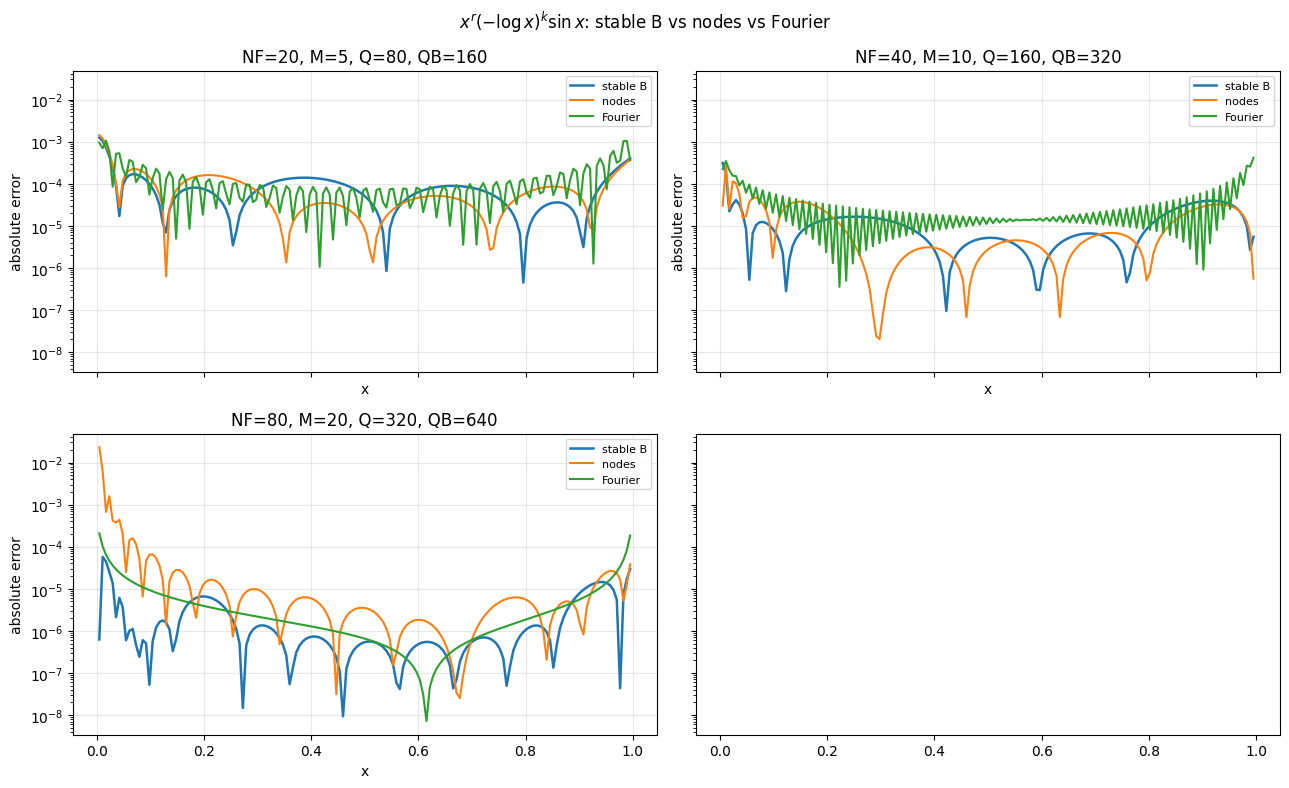

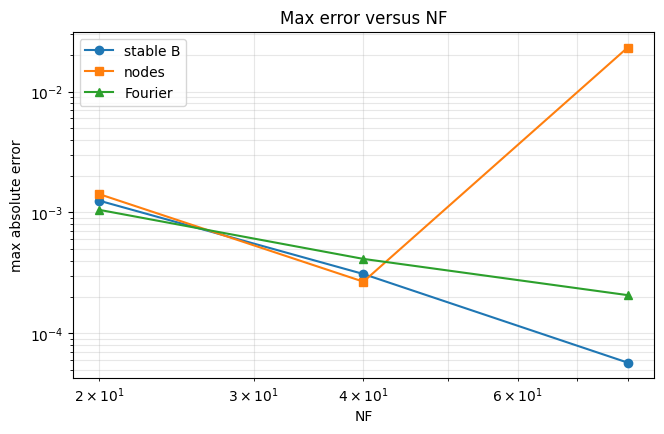

In [5]:

NF_values = [20, 40, 80]
include_slow_nf_160 = False
if include_slow_nf_160:
    NF_values.append(160)
loop_dps = 70
Q_factor = 4
QB_factor = 4
QB_max_factor = 8
loop_B_tol = mp.mpf("1e-4")
M_candidate_fractions = [mp.mpf("0.10"), mp.mpf("0.15"), mp.mpf("0.20"), mp.mpf(gamma)]

# Reuse the Fourier coefficients already computed in Section 2 when possible.
f_hat_cache = {NF: f_hat}
nf_results = []
stability_rows = []

def candidate_m_values(nf_i):
    values = sorted({int(mp.floor(frac * nf_i)) for frac in M_candidate_fractions})
    values = [m_i for m_i in values if m_i >= 0]
    return values or [0]

def diag_relative(diag):
    if diag is None or diag.relative_error_estimate is None:
        return mp.inf
    return diag.relative_error_estimate

for nf_i in NF_values:
    print(f"computing NF={nf_i} ...")
    if nf_i not in f_hat_cache:
        f_hat_cache[nf_i] = fourier_coefficients(f_exact, nf_i, dps=loop_dps)
    f_hat_i = f_hat_cache[nf_i]
    Q_i = Q_factor * nf_i
    QB_i = QB_factor * nf_i
    QB_max_i = QB_max_factor * nf_i

    stable_candidates = []
    for M_i in candidate_m_values(nf_i):
        res_i = fourier_glof_reconstruct(
            f_hat_i,
            r=r_glof,
            z_eval=z_eval,
            k=k,
            alpha=alpha,
            theta=theta,
            M=M_i,
            Q=Q_i,
            QB=QB_i,
            dps=loop_dps,
            coefficient_method="stable_b",
            adaptive_b=True,
            b_tolerance=loop_B_tol,
            q_b_max=QB_max_i,
            b_max_steps=1,
            return_details=True,
        )
        diag_i = res_i.b_diagnostics
        stable_err_i = max_abs_error(f_true, res_i.values)
        stable_candidates.append((res_i, stable_err_i))
        stability_rows.append({
            "NF": nf_i,
            "M": M_i,
            "Q": Q_i,
            "QB_start": QB_i,
            "QB_final": res_i.params.q_b,
            "B_converged": None if diag_i is None else diag_i.converged,
            "B_rel": diag_relative(diag_i),
            "stable_max": stable_err_i,
        })

    converged_candidates = [item for item in stable_candidates if item[0].b_diagnostics and item[0].b_diagnostics.converged]
    if converged_candidates:
        res_stable_i, stable_max_i = converged_candidates[-1]
        selection_rule = "largest converged M"
    else:
        res_stable_i, stable_max_i = min(
            stable_candidates,
            key=lambda item: (diag_relative(item[0].b_diagnostics), -item[0].params.m),
        )
        selection_rule = "smallest B relative estimate, largest M tie-break"

    res_nodes_i = fourier_glof_reconstruct(
        f_hat_i,
        r=r_glof,
        z_eval=z_eval,
        k=k,
        alpha=alpha,
        theta=theta,
        M=res_stable_i.params.m,
        Q=Q_i,
        dps=loop_dps,
        coefficient_method="nodes",
        return_details=True,
    )
    F_i = fourier_partial_sum(f_hat_i, z_eval, nf=nf_i)

    stable_err = [abs(f_true[j] - res_stable_i.values[j]) for j in range(len(z_eval))]
    nodes_err = [abs(f_true[j] - res_nodes_i.values[j]) for j in range(len(z_eval))]
    fourier_err = [abs(f_true[j] - F_i[j]) for j in range(len(z_eval))]

    nf_results.append({
        "NF": nf_i,
        "M": res_stable_i.params.m,
        "Q": Q_i,
        "QB": res_stable_i.params.q_b,
        "B_converged": res_stable_i.b_diagnostics.converged,
        "B_rel": diag_relative(res_stable_i.b_diagnostics),
        "selection_rule": selection_rule,
        "stable_err": stable_err,
        "nodes_err": nodes_err,
        "fourier_err": fourier_err,
        "stable_max": max(stable_err),
        "nodes_max": max(nodes_err),
        "fourier_max": max(fourier_err),
        "stable_rms": rms_error(f_true, res_stable_i.values),
        "nodes_rms": rms_error(f_true, res_nodes_i.values),
        "fourier_rms": rms_error(f_true, F_i),
    })

print("\nB-quadrature stability table")
print(" NF   M    Q  QB0 QBf  conv       B rel est     stable_B max")
for row in stability_rows:
    rel_text = "inf" if row["B_rel"] == mp.inf else mp.nstr(row["B_rel"], 8)
    print(
        f"{row['NF']:3d} {row['M']:3d} {row['Q']:4d} {row['QB_start']:4d} {row['QB_final']:4d}  "
        f"{str(row['B_converged']):>5}  {rel_text:>14}  {mp.nstr(row['stable_max'], 10):>15}"
    )

print("\nselected max / RMS error table")
print(" NF   M    Q   QB  conv       B rel est     stable_B max    nodes max       Fourier max      stable_B rms    nodes rms       Fourier rms")
for row in nf_results:
    rel_text = "inf" if row["B_rel"] == mp.inf else mp.nstr(row["B_rel"], 8)
    print(
        f"{row['NF']:3d} {row['M']:3d} {row['Q']:4d} {row['QB']:4d}  {str(row['B_converged']):>5}  {rel_text:>14}  "
        f"{mp.nstr(row['stable_max'], 10):>15}  {mp.nstr(row['nodes_max'], 10):>13}  {mp.nstr(row['fourier_max'], 10):>15}  "
        f"{mp.nstr(row['stable_rms'], 10):>15}  {mp.nstr(row['nodes_rms'], 10):>13}  {mp.nstr(row['fourier_rms'], 10):>15}"
    )

x_plot = [float(z) for z in z_eval]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, row in zip(axes, nf_results):
    ax.semilogy(x_plot, [float(e) for e in row["stable_err"]], label="stable B", linewidth=1.8)
    ax.semilogy(x_plot, [float(e) for e in row["nodes_err"]], label="nodes", linewidth=1.5)
    ax.semilogy(x_plot, [float(e) for e in row["fourier_err"]], label="Fourier", linewidth=1.5)
    ax.set_title(f"NF={row['NF']}, M={row['M']}, Q={row['Q']}, QB={row['QB']}")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("absolute error")
    ax.legend(fontsize=8)

plt.suptitle(r"$x^r(-\log x)^k\sin x$: stable B vs nodes vs Fourier")
plt.tight_layout()
plt.show()

# Compact convergence view: max error as a function of NF.
plt.figure(figsize=(7.5, 4.5))
nf_axis = [row["NF"] for row in nf_results]
plt.loglog(nf_axis, [float(row["stable_max"]) for row in nf_results], "o-", label="stable B")
plt.loglog(nf_axis, [float(row["nodes_max"]) for row in nf_results], "s-", label="nodes")
plt.loglog(nf_axis, [float(row["fourier_max"]) for row in nf_results], "^-", label="Fourier")
plt.xlabel("NF")
plt.ylabel("max absolute error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Max error versus NF")
plt.show()


## 5. Coefficients

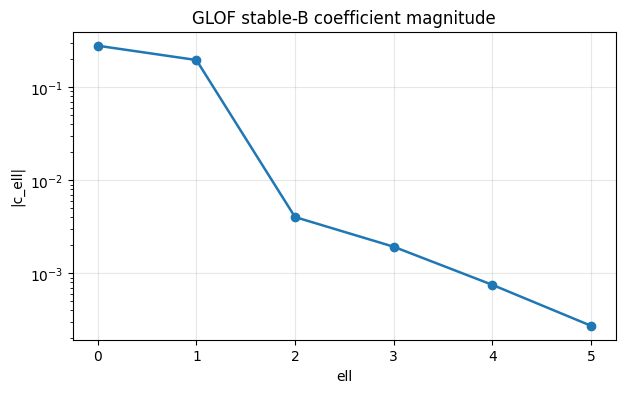

c_stable[0] = (0.2789988484491 + 0.0j)
c_stable[1] = (-0.19586042959872 + 0.0j)
c_stable[2] = (0.0040240757258394 + 0.0j)
c_stable[3] = (0.0019309932732094 + 0.0j)
c_stable[4] = (0.00075220464564204 + 0.0j)
c_stable[5] = (0.00027345305792345 + 0.0j)

Legacy node-path coefficients:
c_nodes[0] = (0.27899714926248 + 0.0j)
c_nodes[1] = (-0.1958283293182 + 0.0j)
c_nodes[2] = (0.0039945646064305 + 0.0j)
c_nodes[3] = (0.0019205367666023 + 0.0j)
c_nodes[4] = (0.00076517526234953 + 0.0j)
c_nodes[5] = (0.00028044768565747 + 0.0j)


In [6]:
ells = list(range(len(result.coefficients)))
coeff_abs = [float(abs(c)) for c in result.coefficients]

plt.figure(figsize=(7, 4))
plt.semilogy(ells, coeff_abs, "o-", linewidth=1.8)
plt.xlabel("ell")
plt.ylabel("|c_ell|")
plt.title("GLOF stable-B coefficient magnitude")
plt.grid(True, alpha=0.3)
plt.show()

for ell, coeff in enumerate(result.coefficients):
    print(f"c_stable[{ell}] = {mp.nstr(coeff, 14)}")

print("\nLegacy node-path coefficients:")
for ell, coeff in enumerate(result_nodes.coefficients):
    print(f"c_nodes[{ell}] = {mp.nstr(coeff, 14)}")

## 6. Small Convergence Table

In [7]:

rows = []
for nf_i in [8, 12, 16, 20]:
    f_hat_i = fourier_coefficients(f_exact, nf_i, dps=70)
    res_stable_i = fourier_glof_reconstruct(
        f_hat_i,
        r=r_glof,
        z_eval=z_eval,
        k=k,
        alpha=alpha,
        theta=theta,
        gamma=gamma,
        Q=4 * nf_i,
        QB=8 * nf_i,
        dps=70,
        coefficient_method="stable_b",
        adaptive_b=True,
        b_tolerance=B_tol,
        q_b_max=16 * nf_i,
        b_max_steps=1,
        return_details=True,
    )
    res_nodes_i = fourier_glof_reconstruct(
        f_hat_i,
        r=r_glof,
        z_eval=z_eval,
        k=k,
        alpha=alpha,
        theta=theta,
        gamma=gamma,
        Q=4 * nf_i,
        dps=70,
        coefficient_method="nodes",
        return_details=True,
    )
    F_i = fourier_partial_sum(f_hat_i, z_eval, nf=nf_i)
    stable_err_i = max_abs_error(f_true, res_stable_i.values)
    nodes_err_i = max_abs_error(f_true, res_nodes_i.values)
    fourier_err_i = max_abs_error(f_true, F_i)
    diag_i = res_stable_i.b_diagnostics
    rows.append((
        nf_i,
        res_stable_i.params.m,
        res_stable_i.params.q,
        res_stable_i.params.q_b,
        None if diag_i is None else diag_i.converged,
        None if diag_i is None else diag_i.relative_error_estimate,
        stable_err_i,
        nodes_err_i,
        fourier_err_i,
    ))

print(" NF   M    Q   QB  conv       B rel est     stable_B        nodes           Fourier")
for nf_i, m_i, q_i, qb_i, conv_i, rel_i, stable_err_i, nodes_err_i, fourier_err_i in rows:
    rel_text = "None" if rel_i is None else mp.nstr(rel_i, 8)
    print(
        f"{nf_i:3d} {m_i:3d} {q_i:4d} {qb_i:4d}  {str(conv_i):>5}  {rel_text:>14}  "
        f"{mp.nstr(stable_err_i, 12):>14}  {mp.nstr(nodes_err_i, 12):>14}  {mp.nstr(fourier_err_i, 12):>14}"
    )


 NF   M    Q   QB  conv       B rel est     stable_B        nodes           Fourier
  8   2   32  128  False   0.00020913898  0.0102323072954  0.0104149305981  0.00572458669506
 12   3   48  192  False   0.00022820842  0.00469274244336  0.00502469201363  0.00299676560497
 16   4   64  256   True    5.1687368e-5  0.00212899477122  0.00250287229784  0.00168388978666
 20   5   80  320   True    5.1890097e-5  0.0013923998008  0.00141893482955  0.00105155360378
